# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
dados = pd.DataFrame(registros)

print("Primeiros registros:")
display(dados.head())

print("Quantidade de linhas e colunas:")
print(dados.shape)

print("\nNomes dos atributos:")
print(dados.columns.tolist())

print("\nInformações do DataFrame:")
dados.info()

print("\nEstatísticas descritivas:")
display(dados.describe())

Primeiros registros:


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


Quantidade de linhas e colunas:
(336, 11)

Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float6

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


### Identificação dos atributos

- **Data/hora:** `dat_referencia` e `din_referenciautc`
- **Área de carga:** `cod_areacarga`
- **Valor de carga:** `val_cargaglobal`

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [7]:
# Renomeando os principais atributos
dados = dados.rename(columns={
    'cod_areacarga': 'area_carga',
    'din_referenciautc': 'data_hora',
    'val_cargaglobal': 'carga'
})

# Criando um DataFrame apenas com os atributos necessários
dados_analise = dados[['area_carga', 'data_hora', 'carga']]

# Verificando valores ausentes
print("Valores ausentes:")
print(dados_analise.isnull().sum())

# Verificando o tipo da variável de carga
print("\nTipo da variável carga:")
print(dados_analise['carga'].dtype)

# Verificando como a data/hora está representada
print("\nExemplo de data/hora:")
print(dados_analise['data_hora'].head())

Valores ausentes:
area_carga    0
data_hora     0
carga         0
dtype: int64

Tipo da variável carga:
float64

Exemplo de data/hora:
0    2025-08-01T03:30:00.000Z
1    2025-08-01T04:00:00.000Z
2    2025-08-01T04:30:00.000Z
3    2025-08-01T05:00:00.000Z
4    2025-08-01T05:30:00.000Z
Name: data_hora, dtype: object


### Decisões de tratamento

Os principais atributos foram renomeados para facilitar a análise.

Foi criado um DataFrame apenas com área de carga, data/hora e carga.

Não existem valores ausentes nos atributos analisados.

A variável de carga está em formato numérico (`float64`).

A data/hora está representada no formato ISO 8601 e foi mantida em seu formato original.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [9]:
carga_minima = dados_analise['carga'].min()
carga_maxima = dados_analise['carga'].max()
carga_media = dados_analise['carga'].mean()
mediana = dados_analise['carga'].median()
amplitude = carga_maxima - carga_minima
total_medicoes = dados_analise['carga'].count()

print("Carga mínima:", carga_minima)
print("Carga máxima:", carga_maxima)
print("Carga média:", carga_media)
print("Mediana:", mediana)
print("Amplitude:", amplitude)
print("Quantidade total de medições:", total_medicoes)

Carga mínima: 12139.253
Carga máxima: 23185.312
Carga média: 17870.828980654762
Mediana: 18199.1285
Amplitude: 11046.059000000001
Quantidade total de medições: 336


### Análise dos indicadores

O valor máximo está acima da média observada, mas não está muito distante do comportamento médio. A carga máxima foi de 23.185,31, enquanto a média foi de 17.870,83. A mediana foi 18.199,13, valor próximo da média, indicando que o máximo representa um pico de carga, mas não está extremamente distante dos valores normalmente observados.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [10]:
# Calculando o limiar de alta demanda
limiar = carga_maxima * 0.90

print("Limiar de alta demanda:", limiar)

# Criando DataFrame com registros acima do limiar
alta_demanda = dados_analise[
    dados_analise['carga'] > limiar
]

# Quantidade de registros
quantidade_alta = alta_demanda.shape[0]

# Percentual em relação ao total
percentual_alta = quantidade_alta / total_medicoes * 100

print("Quantidade de registros de alta demanda:", quantidade_alta)
print(f"Percentual de alta demanda: {percentual_alta:.2f}%")

# Maior valor de carga
maior_valor = alta_demanda['carga'].max()

print("Maior valor de carga:", maior_valor)

# Data e horário do pico
pico = dados_analise.loc[dados_analise['carga'].idxmax()]

print("Data/hora do pico:", pico['data_hora'])

Limiar de alta demanda: 20866.7808
Quantidade de registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Maior valor de carga: 23185.312
Data/hora do pico: 2025-08-01T22:00:00.000Z


### Análise dos períodos de alta demanda

Os períodos próximos ao pico representam uma parcela pequena do período analisado. Foram identificados 50 registros de alta demanda, correspondendo a 14,88% das 336 medições. Portanto, a maior parte do período apresentou valores abaixo de 90% da carga máxima.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [11]:
# Critério: carga acima da média

carga_acima_media = dados_analise[
    dados_analise['carga'] > carga_media
]

# Quantidade de registros
quantidade_media = carga_acima_media.shape[0]

# Percentual
percentual_media = quantidade_media / total_medicoes * 100

print("Critério: carga acima da média")
print("Quantidade de registros:", quantidade_media)
print(f"Percentual: {percentual_media:.2f}%")

# Visualizando o novo DataFrame
display(carga_acima_media.head())

Critério: carga acima da média
Quantidade de registros: 184
Percentual: 54.76%


,area_carga,data_hora,carga
15,SP,2025-08-01T11:00:00.000Z,18096.023
16,SP,2025-08-01T11:30:00.000Z,18629.395
17,SP,2025-08-01T12:00:00.000Z,18825.176
18,SP,2025-08-01T12:30:00.000Z,19056.504
19,SP,2025-08-01T13:00:00.000Z,19427.822


### Critério escolhido

Foi escolhido como segundo critério considerar os registros com carga acima da média.

O novo conjunto possui 184 registros, correspondendo a 54,76% das 336 medições.

Comparando com o conjunto de alta demanda do Desafio 4, que possui 50 registros (14,88%), o critério de carga acima da média seleciona uma quantidade maior de registros. Isso ocorre porque esse critério é menos restritivo que considerar valores acima de 90% da carga máxima.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

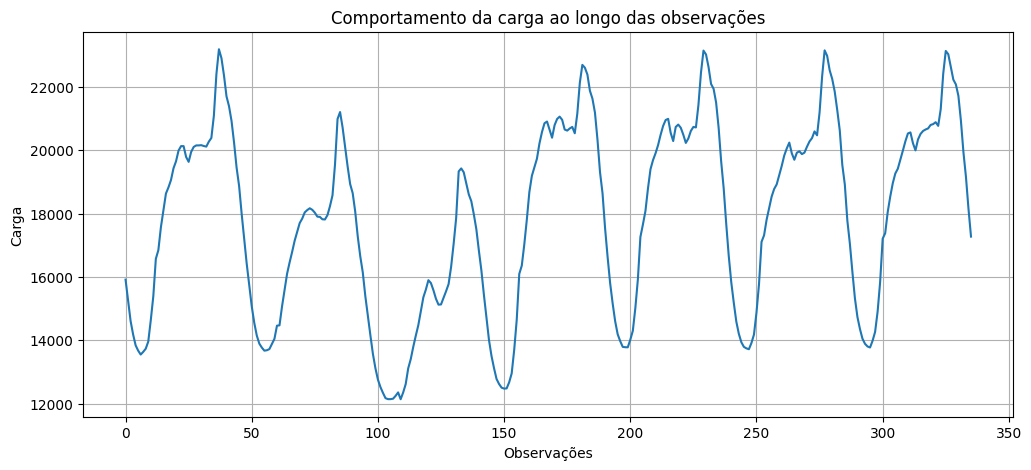

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(dados_analise.index, dados_analise['carga'])

plt.title('Comportamento da carga ao longo das observações')
plt.xlabel('Observações')
plt.ylabel('Carga')
plt.grid(True)

plt.show()

### Interpretação do gráfico 1

A carga apresenta variações ao longo das observações, com períodos de aumento e redução. Também é possível observar que os maiores picos ultrapassam 22.000, enquanto os menores valores ficam próximos de 12.000.

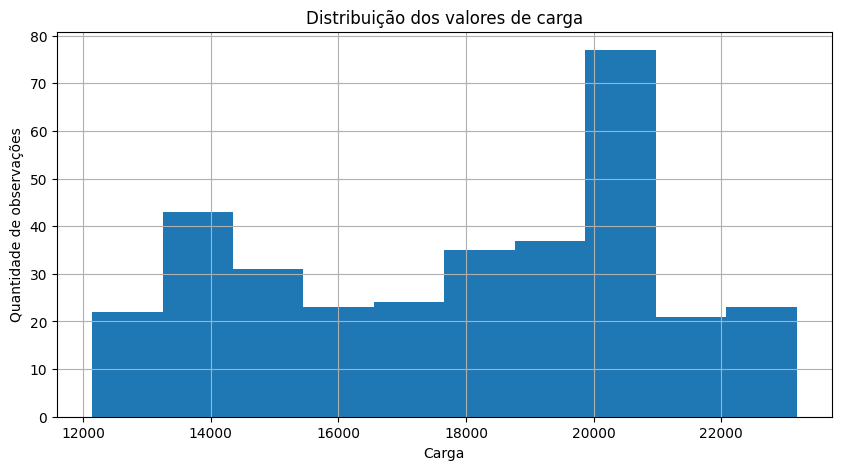

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(dados_analise['carga'], bins=10)

plt.title('Distribuição dos valores de carga')
plt.xlabel('Carga')
plt.ylabel('Quantidade de observações')
plt.grid(True)

plt.show()

### Interpretação do gráfico 2

O histograma mostra a distribuição dos valores de carga. A maior concentração das observações está aproximadamente entre 19.000 e 21.000, enquanto valores muito baixos ou muito altos aparecem com menor frequência.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [14]:
# Período analisado
data_inicio = dados_analise['data_hora'].min()
data_fim = dados_analise['data_hora'].max()

# Momento do pico
pico = dados_analise.loc[dados_analise['carga'].idxmax()]

# Resumo dos resultados
resumo_resultados = f'''
Região analisada: {dados_analise['area_carga'].iloc[0]}
Período analisado: {data_inicio} até {data_fim}
Quantidade de registros: {total_medicoes}
Carga mínima: {carga_minima:.3f}
Carga máxima: {carga_maxima:.3f}
Carga média: {carga_media:.3f}
Mediana: {mediana:.3f}
Limiar de alta demanda: {limiar:.3f}
Registros de alta demanda: {quantidade_alta}
Percentual de alta demanda: {percentual_alta:.2f}%
Momento do pico: {pico['data_hora']}
Segundo critério: carga acima da média
Registros acima da média: {quantidade_media}
Percentual acima da média: {percentual_media:.2f}%
'''

print(resumo_resultados)


Região analisada: SP
Período analisado: 2025-08-01T03:30:00.000Z até 2025-08-08T03:00:00.000Z
Quantidade de registros: 336
Carga mínima: 12139.253
Carga máxima: 23185.312
Carga média: 17870.829
Mediana: 18199.128
Limiar de alta demanda: 20866.781
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 2025-08-01T22:00:00.000Z
Segundo critério: carga acima da média
Registros acima da média: 184
Percentual acima da média: 54.76%



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [15]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 15.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [17]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [18]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [19]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA**

---

### 1. Caracterização do Conjunto Analisado
* **Região:** SP
* **Período do Levantamento:** 2025-08-01T03:30:00.000Z a 2025-08-08T03:00:00.000Z
* **Total de Registros Avaliados:** 336

---

### 2. Principais Indicadores
* **Carga Mínima:** 12.139,253
* **Carga Máxima (Pico):** 23.185,312
* **Momento do Pico de Carga:** 2025-08-01T22:00:00.000Z
* **Carga Média:** 17.870,829
* **Mediana:** 18.199,128

---

### 3. Análise dos Períodos de Alta Demanda
* **Limiar de Alta Demanda:** Cargas iguais ou superiores a 20.866,781.
* **Volume de Registros em Alta Demanda:** 50 registros.
* **Proporção no Período:** 14,88% do total analisado.

*Nota de Análise:* Os dados confirmam a ocorrência do valor máximo de demanda no início da série temporal analisada (01/08/2025 às 22:00:00.000Z). Quaisquer fatores causais para a elevação da demanda até o limiar estipulado (como variáveis meteorológicas, comportamentais ou operacionais) constituem **hipó

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

### Validação crítica

**1. Os indicadores foram utilizados corretamente?**

Sim. Os indicadores apresentados no relatório estão de acordo com os cálculos realizados pela equipe. Os valores de carga mínima, máxima, média, mediana, limiar de alta demanda, quantidade de registros e percentuais estão corretos.

**2. Há alguma afirmação que não pode ser confirmada pelos dados?**

Sim. A afirmação de que a maioria dos registros está na "metade superior da distribuição de carga" não pode ser confirmada apenas pelo fato de 54,76% dos registros estarem acima da média.

**3. Houve interpretação exagerada ou causalidade não demonstrada?**

Não foram identificadas causas inventadas para as variações da carga. O relatório deixou claro que possíveis causas das variações não podem ser determinadas somente pelos dados analisados.

**4. Que alterações a equipe realizou no texto?**

A equipe retirou a afirmação sobre a "metade superior da distribuição", pois estar acima da média não significa necessariamente estar na metade superior da distribuição. Os demais resultados foram mantidos por estarem de acordo com os cálculos realizados.

## Relatório final

### Análise da carga elétrica da região SP

Foi analisada a carga elétrica da região SP em 336 registros, no período de 01/08/2025 a 08/08/2025. A carga mínima registrada foi de 12.139,253 e a máxima foi de 23.185,312. A carga média foi de 17.870,829 e a mediana foi de 18.199,128.

Para identificar períodos de alta demanda, foi utilizado como limiar 90% da carga máxima, resultando em 20.866,781. Foram encontrados 50 registros acima desse valor, correspondendo a 14,88% do total. O maior valor de carga ocorreu em 01/08/2025 às 22:00 UTC.

Como segundo critério, foram considerados os registros com carga acima da média. Esse conjunto apresentou 184 registros, correspondendo a 54,76% do total. Portanto, o segundo critério selecionou uma quantidade maior de registros do que o critério de alta demanda, pois utiliza um limite menos restritivo.

### Conclusão

Os resultados mostram que os períodos de alta demanda representam uma parcela menor do período analisado, enquanto os registros acima da média representam mais da metade das observações. Os dados permitem identificar os períodos de maior carga e comparar os diferentes critérios, mas não permitem determinar as causas das variações observadas.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**